<a href="https://colab.research.google.com/github/bushrafaisal2788-byte/kaggle-rice-plant-dataset/blob/main/Pet_Groom_Salon_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data loaded
46 records

Groom Time Statistics

 Small Dogs
Average: 16.9 minutes
Median: 15.0 minutes
Min: 10 minutes
Max: 25 minutes

 Medium Dogs
Average: 22.0 minutes
Median: 21.0 minutes
Min: 14 minutes
Max: 35 minutes

 Large Dogs
Average: 21.4 minutes
Median: 18.0 minutes
Min: 18 minutes
Max: 27 minutes




/tmp/ipykernel_7963/2041063508.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot(


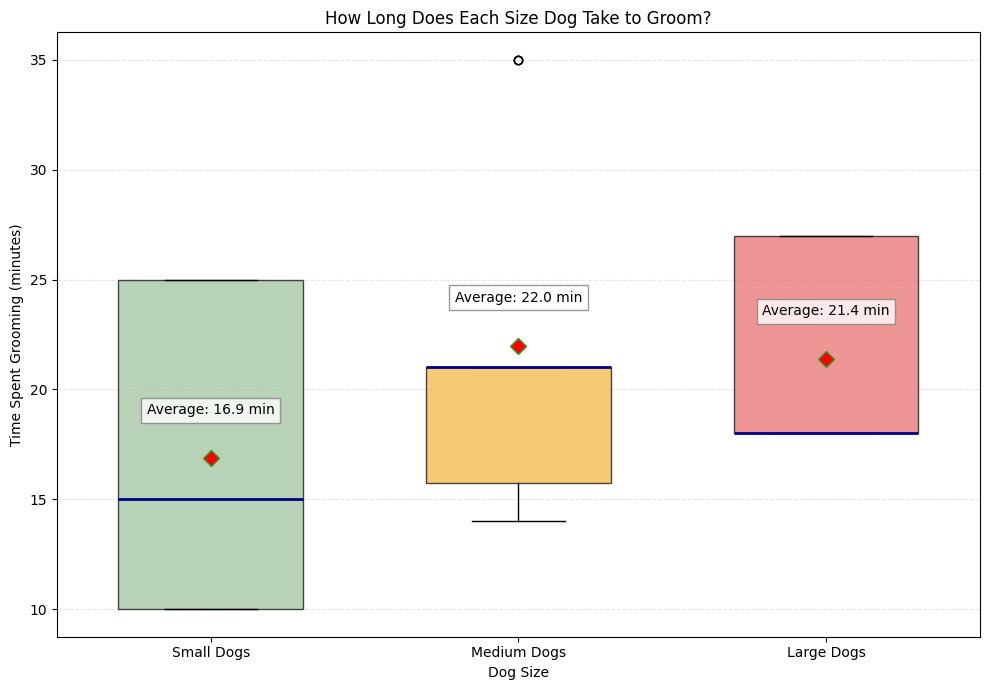

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# Load data
grooming_records = pd.read_excel('/content/4e6fc2288054d6b352b7560b5b3932e2mutznutzbookingsystem___cw_task_2_visualisations.xlsx')

print("Data loaded")
print(len(grooming_records), "records")
print()


# Adjust time by dog size
def calculate_adjusted_time(each_row):
    original_time = each_row['GroomTime']

    if each_row['Size'] == 'Large':
        return original_time * 1.8

    elif each_row['Size'] == 'Medium':
        return original_time * 1.4

    else:
        return original_time * 1.0


grooming_records['Actual_Groom_Time'] = grooming_records.apply(
    calculate_adjusted_time, axis=1
)


# Show stats
print("Groom Time Statistics")
print("="*40)

dog_sizes = ['Small', 'Medium', 'Large']

for each_size in dog_sizes:

    times_for_this_size = grooming_records[
        grooming_records['Size'] == each_size
    ]['Actual_Groom_Time']

    print("\n", each_size, "Dogs")
    print("Average:", f"{times_for_this_size.mean():.1f}", "minutes")
    print("Median:", f"{times_for_this_size.median():.1f}", "minutes")
    print("Min:", f"{times_for_this_size.min():.0f}", "minutes")
    print("Max:", f"{times_for_this_size.max():.0f}", "minutes")

print("\n" + "="*40 + "\n")


# Prepare data for box plot
plt.figure(figsize=(10, 7))

small_dog_times = grooming_records[
    grooming_records['Size'] == 'Small'
]['Actual_Groom_Time']

medium_dog_times = grooming_records[
    grooming_records['Size'] == 'Medium'
]['Actual_Groom_Time']

large_dog_times = grooming_records[
    grooming_records['Size'] == 'Large'
]['Actual_Groom_Time']


# Create box plot
box_plot = plt.boxplot(
    [small_dog_times, medium_dog_times, large_dog_times],
    labels=['Small Dogs', 'Medium Dogs', 'Large Dogs'],
    patch_artist=True,
    widths=0.6,
    showmeans=True,
    meanprops={'marker': 'D', 'markerfacecolor': 'red', 'markersize': 8}
)


# Colors
box_colours = ['#9BBF9B', '#F3B33D', '#E86A6A']

for box, colour in zip(box_plot['boxes'], box_colours):
    box.set_facecolor(colour)
    box.set_alpha(0.7)


for median_line in box_plot['medians']:
    median_line.set_color('darkblue')
    median_line.set_linewidth(2)


# Titles
plt.title('How Long Does Each Size Dog Take to Groom?')
plt.ylabel('Time Spent Grooming (minutes)')
plt.xlabel('Dog Size')

plt.grid(True, axis='y', alpha=0.3, linestyle='--')


# Add average text
for position, each_size in enumerate(
    ['Small', 'Medium', 'Large'], start=1
):

    average_time = grooming_records[
        grooming_records['Size'] == each_size
    ]['Actual_Groom_Time'].mean()

    plt.text(
        position,
        average_time + 2,
        f'Average: {average_time:.1f} min',
        ha='center',
        fontsize=10,
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
    )


plt.tight_layout()
plt.show()

